# Multimodal Fusion — EEG / ECG / Eye-Tracker


> - each modality has been trained on individual participants within VR, RW, and domain change
> - each model has validation and test results
> - the fusion takes all the windows for each participant and combines them into window-modality pairs
> - it takes the predictions from all modalities and runs the majority or LR-type vote on it
> - LR is being trained on the validation results of the models

## steps

1. **files** in a folder structure like:
   ```
   fusion_inputs/
   ├── eeg/  ASAF02_windowed_Normalised_NF_VR.csv, ..._RW.csv, ...
   ├── ecg/  ASAF02_windowed_Normalised_NF_VR.csv, ..._RW.csv, ...
   └── eye/  ASAF02_windowed_Normalised_NF_VR.csv, ..._RW.csv, ...
   ```
2. **Coverage matrix**: who has which modalities in which world.
3. **Intersection cohort**: participants present in all modalities — fusion runs here, baselines run on the same cohort so the comparison is fair.
4. **Per-modality LOO-CV**: 12 trials → 12 leave-one-out folds → linear SVM per fold → out-of-fold (OOF) predictions and probabilities. **These OOF predictions are the "validation results" the LR meta-learner will train on.**
5. **Cross-domain**: train all-VR, predict all-RW (and vice versa). No CV.
6. **Late fusion — majority vote**: each modality predicts a class, ties broken by summed probability across modalities.
7. **Late fusion — LR stacking**: stack each modality's OOF probability vectors into a meta-feature matrix; LOO-CV with logistic regression on top. Honest by construction (inputs are already OOF).
8. **Comparison table**: BAC for every (single modality, pairwise, tri-modal) × (VR, RW, VR→RW, RW→VR) × task. Saved to CSV.

## On the validation question

With only 12 trials per `(participant, world)`, leave-one-trial-out is the right protocol. Each trial is held out once. The 12 OOF predictions per participant per modality are the "validation results". The LR stacker trains on those. If you want a clean test estimate of the stacker itself, swap the inner loop for nested CV — left as a comment in cell 7.

## On the time-alignment

The trial-level CSVs were each built from the same windows per trial (because every modality uses `stable_hash(participant, scene_id, world, ws, MASTER_SEED=42)`). So when we mean-aggregate windows to trial level, modalities are over comparable time slices. The fusion join key is `(world, trial_id)`. If you later switch to window-level fusion, change `JOIN_KEY` to `('world', 'trial_id', 'window_idx')` and everything else still works.

## Master seed = 42 throughout.

## 1. Configuration

Point `FUSION_ROOT` at the parent folder containing your `eeg/`, `ecg/`, `eye/` subfolders. Set `OUT_DIR` to where you want the fusion outputs written.

In [38]:
import re, json, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════
# CONFIG — edit these two paths
# ═══════════════════════════════════════════════════════════
FUSION_ROOT = Path('/home/prakunjpratapsingh/deeplearning/converge/Researchquestion/fusion_inputs')
OUT_DIR     = Path('/home/prakunjpratapsingh/deeplearning/fusion_outputs')
# MODALITIES  = ['eeg', 'ecg', 'eye']      # subfolder names under FUSION_ROOT
MODALITIES  = ['eeg', 'ecg'] 

MASTER_SEED = 42                          # SAME as EEG / ECG / eye pipelines
WORLDS = ('VR', 'RW')

# Trial-level join key. Change to ('world','trial_id','window_idx') for window-level fusion.
JOIN_KEY = ['world', 'trial_id']

# Metadata columns are the same across modalities
META_COLS = {'world','participant_id','trial_id','level','trial',
             'n_valid_windows','used_duration'}

# Filename pattern: <PID>_windowed_Normalised_NF_<WORLD>.csv
FNAME_RE = re.compile(r'^(?P<pid>[A-Z0-9]+)_windowed_Normalised_NF_(?P<world>VR|RW)\.csv$')

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'FUSION_ROOT = {FUSION_ROOT}')
print(f'OUT_DIR     = {OUT_DIR}')
print(f'MODALITIES  = {MODALITIES}')

FUSION_ROOT = /home/prakunjpratapsingh/deeplearning/converge/Researchquestion/fusion_inputs
OUT_DIR     = /home/prakunjpratapsingh/deeplearning/fusion_outputs
MODALITIES  = ['eeg', 'ecg']


## 2. Tasks to evaluate

Every classification task is defined as `level → label` (`None` drops a trial). All tasks run in **VR**, **RW**, **VR→RW**, and **RW→VR**.

| Task | Description |
|---|---|
| L1 vs L2 | 8 vs 12 obj, both Image Whole Duration |
| L3 vs L4 | 8 vs 12 obj, both Image 30s |
| L1 vs L3 | Image Whole vs 30s, both 8 obj |
| L2 vs L4 | Image Whole vs 30s, both 12 obj |
| 8 vs 12 obj (collapsed) | L1+L3 vs L2+L4 — pure object-load contrast |
| Image Whole vs 30s (collapsed) | L1+L2 vs L3+L4 — pure presentation-mode contrast |
| 4-class | L1 / L2 / L3 / L4 |

In [39]:
def _task(*keep, label_map):
    keep = set(keep)
    def _fn(level):
        return label_map.get(level) if level in keep else None
    return _fn

TASKS = {
    'L1_vs_L2 (8 vs 12 obj, Image Whole Duration)':
        _task(1, 2, label_map={1: 0, 2: 1}),
    'L3_vs_L4 (8 vs 12 obj, Image 30s)':
        _task(3, 4, label_map={3: 0, 4: 1}),
    'L1_vs_L3 (Image Whole vs 30s, 8 obj)':
        _task(1, 3, label_map={1: 0, 3: 1}),
    'L2_vs_L4 (Image Whole vs 30s, 12 obj)':
        _task(2, 4, label_map={2: 0, 4: 1}),
    '8_vs_12_obj (collapsed)':
        _task(1, 2, 3, 4, label_map={1: 0, 2: 1, 3: 0, 4: 1}),
    'Image_Whole_vs_30s (collapsed)':
        _task(1, 2, 3, 4, label_map={1: 0, 2: 0, 3: 1, 4: 1}),
    '4-Class (L1_L2_L3_L4)':
        _task(1, 2, 3, 4, label_map={1: 0, 2: 1, 3: 2, 4: 3}),
}
print(f'{len(TASKS)} tasks defined')

7 tasks defined


## 3. files and build the coverage matrix

Walk `FUSION_ROOT/<modality>/*.csv`, extract `(participant, world)` from each filename. The coverage matrix shows ✓ / · for every cell. The **intersection cohort** per world = participants with ✓ in every modality.

In [40]:
def discover_files(root: Path, modalities):
    found = {}
    for mod in modalities:
        mod_dir = next((d for d in root.iterdir() if d.is_dir() and d.name.lower() == mod.lower()), None)
        if mod_dir is None:
            print(f'[WARN] No subfolder for modality "{mod}" under {root}')
            found[mod] = {}
            continue
        files = {}
        for csv in mod_dir.glob('*.csv'):
            m = FNAME_RE.match(csv.name)
            if m:
                files[(m.group('pid'), m.group('world'))] = csv
        found[mod] = files
        print(f'  [{mod}] {len(files)} files in {mod_dir}')
    return found

def coverage_matrix(found):
    pids = sorted({pid for mod in found.values() for (pid, _) in mod})
    rows = []
    for pid in pids:
        row = {'participant_id': pid}
        for mod in found:
            for w in WORLDS:
                row[f'{mod}_{w}'] = '✓' if (pid, w) in found[mod] else '·'
        rows.append(row)
    return pd.DataFrame(rows)

def intersection_cohort(found, world):
    if not found:
        return []
    sets = [{pid for (pid, w) in mod_files if w == world} for mod_files in found.values()]
    return sorted(set.intersection(*sets)) if sets else []

found = discover_files(FUSION_ROOT, MODALITIES)
cov = coverage_matrix(found)
print('\nCoverage matrix:')
print(cov.to_string(index=False))
cov.to_csv(OUT_DIR / 'coverage_matrix.csv', index=False)

cohort = {w: intersection_cohort(found, w) for w in WORLDS}
print('\nIntersection cohort:')
for w, ps in cohort.items():
    print(f'  {w}: {ps}')

  [eeg] 14 files in /home/prakunjpratapsingh/deeplearning/converge/Researchquestion/fusion_inputs/eeg
  [ecg] 10 files in /home/prakunjpratapsingh/deeplearning/converge/Researchquestion/fusion_inputs/ecg

Coverage matrix:
participant_id eeg_VR eeg_RW ecg_VR ecg_RW
        ASAF02      ✓      ✓      ·      ·
        JAGO02      ✓      ✓      ✓      ✓
        RUSA03      ✓      ✓      ✓      ✓
        SRBH00      ✓      ✓      ·      ·
        UPDE00      ✓      ✓      ✓      ✓
        VIAN01      ✓      ✓      ✓      ✓
        WAAR02      ✓      ✓      ✓      ✓

Intersection cohort:
  VR: ['JAGO02', 'RUSA03', 'UPDE00', 'VIAN01', 'WAAR02']
  RW: ['JAGO02', 'RUSA03', 'UPDE00', 'VIAN01', 'WAAR02']


## 4. Per-modality LOO-CV (the "validation results")

For each `(participant, world, task, modality)`:

- 12 trials → 12 leave-one-out folds.
- Each fold: `StandardScaler.fit(train) → SVC(kernel='linear', C=0.01, class_weight='balanced').fit → predict_proba(test_trial)`.
- Output: one row per trial with `y_true, y_pred, p_class_0, p_class_1, ...`

This is the **out-of-fold (OOF) prediction table** per modality. It serves two purposes:
1. Per-modality baseline BAC (= correct fraction across the 12 trials).
2. Input to the LR stacker — the "validation results" it trains on.

Cross-domain: train on all 12 source-world trials, predict all 12 target-world trials. No CV.

In [41]:
def make_classifier():
    return SVC(kernel='linear', C=0.01, class_weight='balanced',
               probability=True, random_state=MASTER_SEED)

def load_modality_csv(path):
    df = pd.read_csv(path)
    df['world'] = df['world'].astype(str).str.upper()
    return df

def _features(df):
    return [c for c in df.columns if c not in META_COLS]

def loo_predictions_within_world(df, task_fn):
    """LOO-CV within one (participant, world) for one task. Returns OOF predictions."""
    df = df.copy()
    df['y'] = df['level'].map(task_fn)
    df = df[df['y'].notna()].reset_index(drop=True)
    if df.empty or df['y'].nunique() < 2:
        return None

    feats = _features(df)
    X = df[feats].to_numpy(float)
    y = df['y'].to_numpy(int)
    n_classes = int(np.max(y)) + 1

    out_pred = np.full(len(df), -1, dtype=int)
    out_proba = np.zeros((len(df), n_classes), dtype=float)

    for tr, te in LeaveOneOut().split(X):
        scaler = StandardScaler().fit(X[tr])
        Xtr, Xte = scaler.transform(X[tr]), scaler.transform(X[te])

        if len(np.unique(y[tr])) < 2:
            out_pred[te[0]] = int(np.bincount(y[tr]).argmax())
            out_proba[te[0], out_pred[te[0]]] = 1.0
            continue

        clf = make_classifier().fit(Xtr, y[tr])
        out_pred[te[0]] = int(clf.predict(Xte)[0])
        proba_row = clf.predict_proba(Xte)[0]
        for cls_idx, cls in enumerate(clf.classes_):
            out_proba[te[0], int(cls)] = proba_row[cls_idx]

    out = df[['trial_id', 'level', 'trial']].copy()
    out['y_true'] = y
    out['y_pred'] = out_pred
    for c in range(n_classes):
        out[f'p_class_{c}'] = out_proba[:, c]
    return out

def cross_domain_predictions(df_train, df_test, task_fn):
    """Train on one world, predict the other. No CV — fixed train/test split."""
    df_tr = df_train.copy(); df_tr['y'] = df_tr['level'].map(task_fn)
    df_te = df_test.copy();  df_te['y'] = df_te['level'].map(task_fn)
    df_tr = df_tr[df_tr['y'].notna()].reset_index(drop=True)
    df_te = df_te[df_te['y'].notna()].reset_index(drop=True)
    if df_tr.empty or df_te.empty or df_tr['y'].nunique() < 2:
        return None

    feats = _features(df_tr)
    Xtr, ytr = df_tr[feats].to_numpy(float), df_tr['y'].to_numpy(int)
    Xte, yte = df_te[feats].to_numpy(float), df_te['y'].to_numpy(int)
    n_classes = int(max(ytr.max(), yte.max())) + 1

    scaler = StandardScaler().fit(Xtr)
    clf = make_classifier().fit(scaler.transform(Xtr), ytr)
    pred = clf.predict(scaler.transform(Xte)).astype(int)
    raw_proba = clf.predict_proba(scaler.transform(Xte))
    proba = np.zeros((len(yte), n_classes))
    for cls_idx, cls in enumerate(clf.classes_):
        proba[:, int(cls)] = raw_proba[:, cls_idx]

    out = df_te[['trial_id', 'level', 'trial']].copy()
    out['y_true'] = yte
    out['y_pred'] = pred
    for c in range(n_classes):
        out[f'p_class_{c}'] = proba[:, c]
    return out

print('Per-modality classifier defined.')

Per-modality classifier defined.


## 5. Late-fusion strategies

**Majority vote** — for each test trial, count modality predictions and pick the most-common class. Ties broken by summed probability mass across modalities (the class with highest summed score wins).

**LR stacker** — stack each modality's OOF probability vector into a meta-feature matrix of shape `(N_trials, N_modalities × N_classes)`. Train a logistic regression on it with leave-one-out CV. Because the inputs are already out-of-fold, no leakage.

In [42]:
def majority_vote(per_modality_preds):
    """Aligns predictions on trial_id and votes."""
    base = next(iter(per_modality_preds.values()))[['trial_id', 'y_true']].copy()
    base = base.set_index('trial_id')

    pred_cols = []
    proba_sum = None
    for mod, df in per_modality_preds.items():
        df = df.set_index('trial_id')
        col = f'pred_{mod}'
        base[col] = df['y_pred']
        pred_cols.append(col)

        proba_cols = [c for c in df.columns if c.startswith('p_class_')]
        renamed = df[proba_cols].rename(columns=lambda c: f'p_{mod}_{c[len("p_class_"):]}')
        proba_sum = renamed if proba_sum is None else proba_sum.add(renamed, fill_value=0.0)

    def _vote(row):
        votes = row[pred_cols].dropna().astype(int).tolist()
        if not votes:
            return -1
        counts = pd.Series(votes).value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1:
            return int(top[0])
        # tie-break by summed probability across modalities for each tied class
        if proba_sum is None:
            return int(top[0])
        scores = {}
        for c in top:
            cols_for_c = [col for col in proba_sum.columns if col.endswith(f'_{c}')]
            scores[c] = float(proba_sum.loc[row.name, cols_for_c].sum())
        return int(max(scores, key=scores.get))

    base['y_pred'] = base.apply(_vote, axis=1)
    return base.reset_index()[['trial_id', 'y_true', 'y_pred'] + pred_cols]

def lr_stacker(per_modality_preds):
    """LR meta-learner trained on OOF probabilities."""
    meta_frames = []
    for mod, df in per_modality_preds.items():
        df = df.copy()
        proba_cols = [c for c in df.columns if c.startswith('p_class_')]
        df = df[['trial_id', 'y_true'] + proba_cols]
        df = df.rename(columns={c: f'{mod}_{c}' for c in proba_cols})
        meta_frames.append(df.set_index('trial_id'))

    merged = meta_frames[0].copy()
    for f in meta_frames[1:]:
        merged = merged.join(f.drop(columns=['y_true'], errors='ignore'), how='inner')

    if merged.empty or merged['y_true'].nunique() < 2:
        return pd.DataFrame(columns=['trial_id', 'y_true', 'y_pred'])

    meta_X_cols = [c for c in merged.columns if c != 'y_true']
    X = merged[meta_X_cols].to_numpy(float)
    y = merged['y_true'].to_numpy(int)

    preds = np.full(len(y), -1, dtype=int)
    for tr, te in LeaveOneOut().split(X):
        if len(np.unique(y[tr])) < 2:
            preds[te[0]] = int(np.bincount(y[tr]).argmax())
            continue
        lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                random_state=MASTER_SEED).fit(X[tr], y[tr])
        preds[te[0]] = int(lr.predict(X[te])[0])

    return pd.DataFrame({'trial_id': merged.index, 'y_true': y, 'y_pred': preds})

print('Fusion strategies defined.')

Fusion strategies defined.


## 6. Run all tasks × all worlds × all modality combinations

For every cell of the comparison table:

- single modality → BAC of OOF predictions
- bi-modal {EEG+ECG, EEG+Eye, ECG+Eye} → vote + LR-stack
- tri-modal {EEG+ECG+Eye} → vote + LR-stack

All computed on the same intersection cohort so the comparison is fair.

In [43]:
def safe_bac(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = (y_pred >= 0)
    if mask.sum() == 0 or len(np.unique(y_true[mask])) < 2:
        return float('nan')
    return float(balanced_accuracy_score(y_true[mask], y_pred[mask]))

# Pre-load every CSV once
cache = {mod: {} for mod in MODALITIES}
for mod, files in found.items():
    for (pid, world), path in files.items():
        cache[mod][(pid, world)] = load_modality_csv(path)

summary_rows = []
pred_log_rows = []

for task_name, task_fn in TASKS.items():
    print(f'── {task_name}')

    # ── within-world ──
    for world in WORLDS:
        participants = cohort[world]
        if not participants:
            continue

        # per-modality OOF predictions
        per_pp_preds = defaultdict(dict)  # per_pp_preds[mod][pid] = OOF df
        for mod in MODALITIES:
            for pid in participants:
                df = cache[mod].get((pid, world))
                if df is None: continue
                pred = loo_predictions_within_world(df, task_fn)
                if pred is not None:
                    per_pp_preds[mod][pid] = pred

        # single-modality BAC averaged across participants
        for mod in MODALITIES:
            bacs = []
            for pid, pred in per_pp_preds[mod].items():
                bac = safe_bac(pred['y_true'], pred['y_pred'])
                bacs.append(bac)
                pred_log_rows.append(dict(task=task_name, world=world,
                                          modality=mod, participant=pid,
                                          bac=bac, n_trials=len(pred)))
            if bacs:
                summary_rows.append(dict(task=task_name, world=world, model=mod,
                    bac_mean=float(np.nanmean(bacs)),
                    bac_std=float(np.nanstd(bacs)),
                    n_participants=len(bacs)))

        # all bi-modal and tri-modal combos
        for k in range(2, len(MODALITIES) + 1):
            for combo in combinations(MODALITIES, k):
                bacs_mv, bacs_lr = [], []
                for pid in participants:
                    per_mod = {m: per_pp_preds[m][pid] for m in combo if pid in per_pp_preds[m]}
                    if len(per_mod) != len(combo):
                        continue
                    mv = majority_vote(per_mod)
                    bacs_mv.append(safe_bac(mv['y_true'], mv['y_pred']))
                    lr = lr_stacker(per_mod)
                    if len(lr):
                        bacs_lr.append(safe_bac(lr['y_true'], lr['y_pred']))
                label = '+'.join(combo)
                if bacs_mv:
                    summary_rows.append(dict(task=task_name, world=world,
                        model=f'{label} (vote)',
                        bac_mean=float(np.nanmean(bacs_mv)),
                        bac_std=float(np.nanstd(bacs_mv)),
                        n_participants=len(bacs_mv)))
                if bacs_lr:
                    summary_rows.append(dict(task=task_name, world=world,
                        model=f'{label} (LR-stack)',
                        bac_mean=float(np.nanmean(bacs_lr)),
                        bac_std=float(np.nanstd(bacs_lr)),
                        n_participants=len(bacs_lr)))

    # ── cross-domain ──
    cross_pids = sorted(set(cohort['VR']) & set(cohort['RW']))
    if not cross_pids:
        continue
    for src, tgt in [('VR','RW'), ('RW','VR')]:
        per_pp_preds = defaultdict(dict)
        for mod in MODALITIES:
            for pid in cross_pids:
                df_tr = cache[mod].get((pid, src)); df_te = cache[mod].get((pid, tgt))
                if df_tr is None or df_te is None: continue
                pred = cross_domain_predictions(df_tr, df_te, task_fn)
                if pred is not None:
                    per_pp_preds[mod][pid] = pred

        for mod in MODALITIES:
            bacs = [safe_bac(p['y_true'], p['y_pred']) for p in per_pp_preds[mod].values()]
            if bacs:
                summary_rows.append(dict(task=task_name, world=f'{src}->{tgt}',
                    model=mod, bac_mean=float(np.nanmean(bacs)),
                    bac_std=float(np.nanstd(bacs)), n_participants=len(bacs)))

        for k in range(2, len(MODALITIES) + 1):
            for combo in combinations(MODALITIES, k):
                bacs_mv, bacs_lr = [], []
                for pid in cross_pids:
                    per_mod = {m: per_pp_preds[m][pid] for m in combo if pid in per_pp_preds[m]}
                    if len(per_mod) != len(combo):
                        continue
                    mv = majority_vote(per_mod)
                    bacs_mv.append(safe_bac(mv['y_true'], mv['y_pred']))
                    lr = lr_stacker(per_mod)
                    if len(lr):
                        bacs_lr.append(safe_bac(lr['y_true'], lr['y_pred']))
                label = '+'.join(combo)
                if bacs_mv:
                    summary_rows.append(dict(task=task_name, world=f'{src}->{tgt}',
                        model=f'{label} (vote)',
                        bac_mean=float(np.nanmean(bacs_mv)),
                        bac_std=float(np.nanstd(bacs_mv)),
                        n_participants=len(bacs_mv)))
                if bacs_lr:
                    summary_rows.append(dict(task=task_name, world=f'{src}->{tgt}',
                        model=f'{label} (LR-stack)',
                        bac_mean=float(np.nanmean(bacs_lr)),
                        bac_std=float(np.nanstd(bacs_lr)),
                        n_participants=len(bacs_lr)))

summary = pd.DataFrame(summary_rows)
if not summary.empty:
    summary = summary.sort_values(['task','world','bac_mean'], ascending=[True,True,False])
summary.to_csv(OUT_DIR / 'fusion_summary.csv', index=False)
pd.DataFrame(pred_log_rows).to_csv(OUT_DIR / 'per_participant_baseline_bac.csv', index=False)

with open(OUT_DIR / 'run_metadata.json', 'w') as f:
    json.dump({
        'master_seed': MASTER_SEED,
        'modalities': MODALITIES,
        'cohort_VR': cohort['VR'],
        'cohort_RW': cohort['RW'],
        'cross_domain_cohort': sorted(set(cohort['VR']) & set(cohort['RW'])),
        'tasks': list(TASKS.keys()),
    }, f, indent=2)
print(f'\nSummary: {len(summary)} rows → {OUT_DIR / "fusion_summary.csv"}')

── L1_vs_L2 (8 vs 12 obj, Image Whole Duration)
── L3_vs_L4 (8 vs 12 obj, Image 30s)
── L1_vs_L3 (Image Whole vs 30s, 8 obj)
── L2_vs_L4 (Image Whole vs 30s, 12 obj)
── 8_vs_12_obj (collapsed)
── Image_Whole_vs_30s (collapsed)
── 4-Class (L1_L2_L3_L4)

Summary: 112 rows → /home/prakunjpratapsingh/deeplearning/fusion_outputs/fusion_summary.csv


## 7. Display the comparison table

Pivot per task: rows = model, columns = world (VR / RW / VR→RW / RW→VR), values = mean BAC across participants. This is the table that goes in the paper.

In [44]:
if summary.empty:
    print('No results to display.')
else:
    for task_name, sub in summary.groupby('task', sort=False):
        piv = (sub.pivot_table(index='model', columns='world',
                               values='bac_mean', aggfunc='mean').round(3))
        # consistent column order
        col_order = [c for c in ['VR','RW','VR->RW','RW->VR'] if c in piv.columns]
        piv = piv[col_order]
        print(f'\n── {task_name}  (BAC, mean across participants)')
        print(piv.to_string())


── 4-Class (L1_L2_L3_L4)  (BAC, mean across participants)
world                  VR     RW  VR->RW  RW->VR
model                                           
ecg                 0.333  0.333   0.350   0.233
eeg                 0.350  0.333   0.367   0.333
eeg+ecg (LR-stack)  0.450  0.633   0.333   0.300
eeg+ecg (vote)      0.250  0.167   0.400   0.267

── 8_vs_12_obj (collapsed)  (BAC, mean across participants)
world                  VR    RW  VR->RW  RW->VR
model                                          
ecg                 0.767  0.75   0.600   0.517
eeg                 0.767  0.80   0.567   0.617
eeg+ecg (LR-stack)  0.950  0.95   0.700   0.650
eeg+ecg (vote)      0.600  0.65   0.600   0.467

── Image_Whole_vs_30s (collapsed)  (BAC, mean across participants)
world                  VR     RW  VR->RW  RW->VR
model                                           
ecg                 0.767  0.833   0.583   0.600
eeg                 0.767  0.733   0.700   0.617
eeg+ecg (LR-stack)  0.933  0.950  

## 8. Per-participant breakdown (drill-down)

Useful for the paper supplement: BAC for each `(participant, modality, task, world)` from the single-modality baselines. Already saved as `per_participant_baseline_bac.csv`. Quick view here.

In [46]:
pp = pd.read_csv(OUT_DIR / 'per_participant_baseline_bac.csv')

if pp.empty:
    print('No per-participant rows.')
else:
    for task_name, sub in pp.groupby('task', sort=False):

        pivot = sub.pivot_table(
            index='participant',
            columns=['modality','world'],
            values='bac',
            aggfunc='mean'
        ).round(3)

        print(f'\n── {task_name} (per participant BAC)')
        print(pivot.to_string())

print(f'\n(Full file: {OUT_DIR}/per_participant_baseline_bac.csv)')


── L1_vs_L2 (8 vs 12 obj, Image Whole Duration) (per participant BAC)
modality       ecg           eeg       
world           RW     VR     RW     VR
participant                            
JAGO02       0.833  0.667  0.833  1.000
RUSA03       0.833  0.833  0.833  0.833
UPDE00       0.833  1.000  0.667  0.833
VIAN01       0.667  0.667  0.667  1.000
WAAR02       0.667  0.833  1.000  0.833

── L3_vs_L4 (8 vs 12 obj, Image 30s) (per participant BAC)
modality       ecg           eeg       
world           RW     VR     RW     VR
participant                            
JAGO02       0.667  0.833  0.833  0.833
RUSA03       0.833  0.833  0.833  0.500
UPDE00       0.500  0.500  0.833  1.000
VIAN01       0.833  0.833  0.667  0.833
WAAR02       0.833  0.833  1.000  0.667

── L1_vs_L3 (Image Whole vs 30s, 8 obj) (per participant BAC)
modality       ecg           eeg       
world           RW     VR     RW     VR
participant                            
JAGO02       0.833  1.000  1.000  1.000
RUSA03

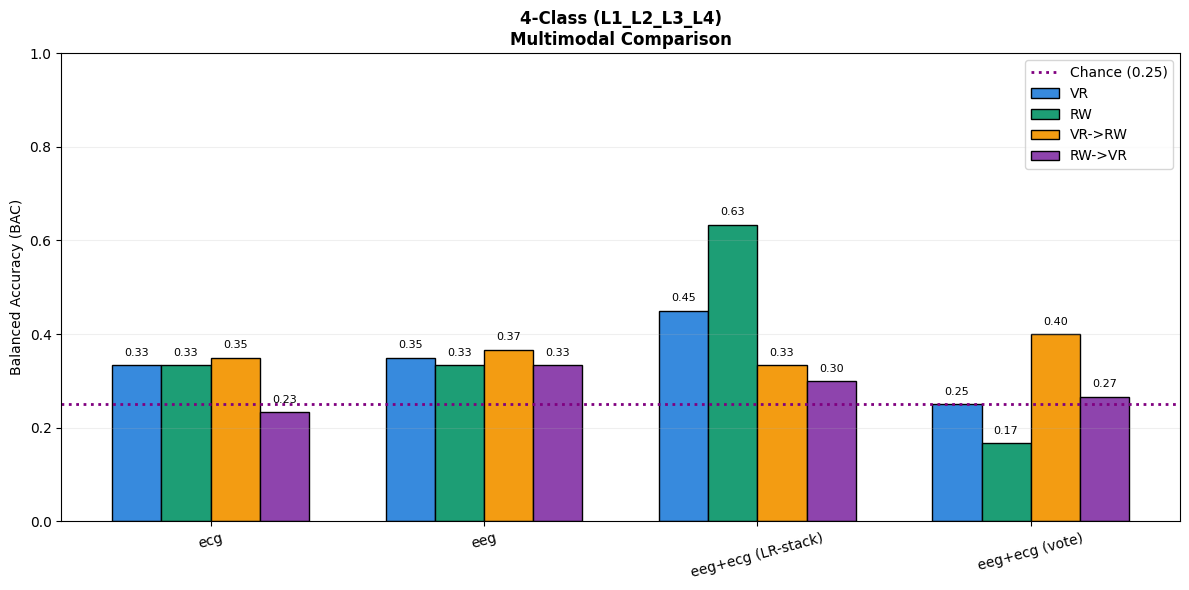

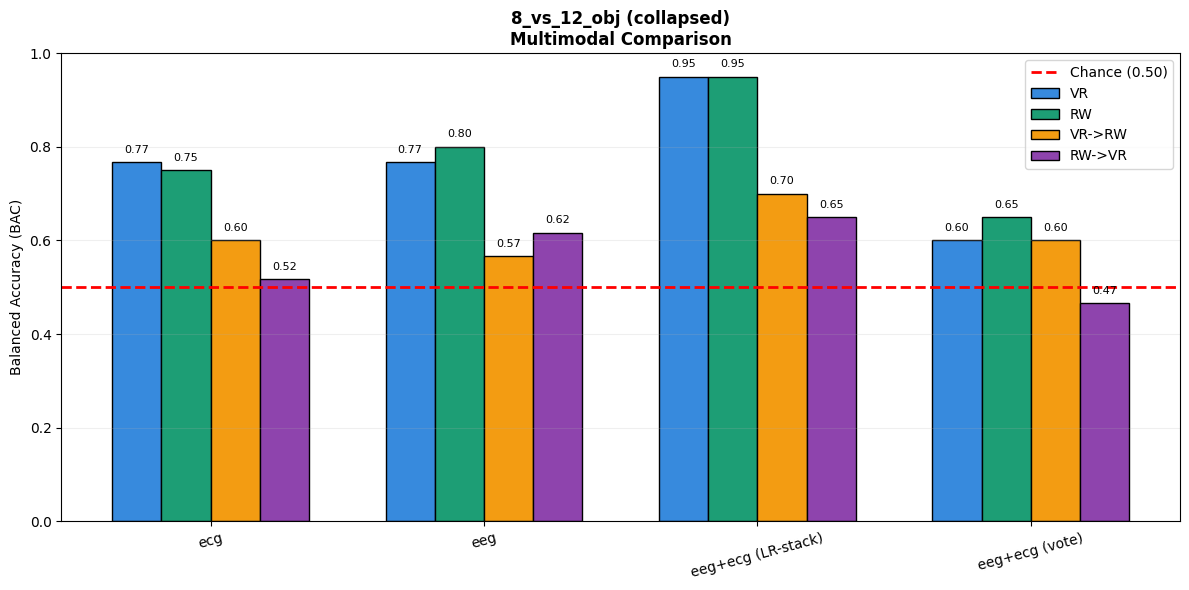

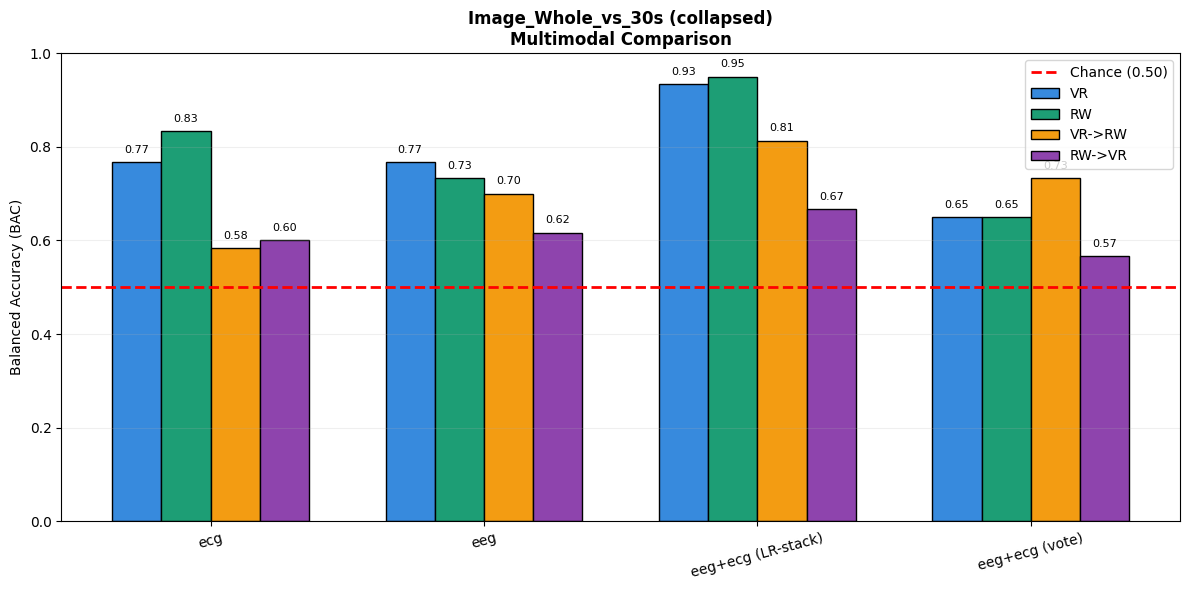

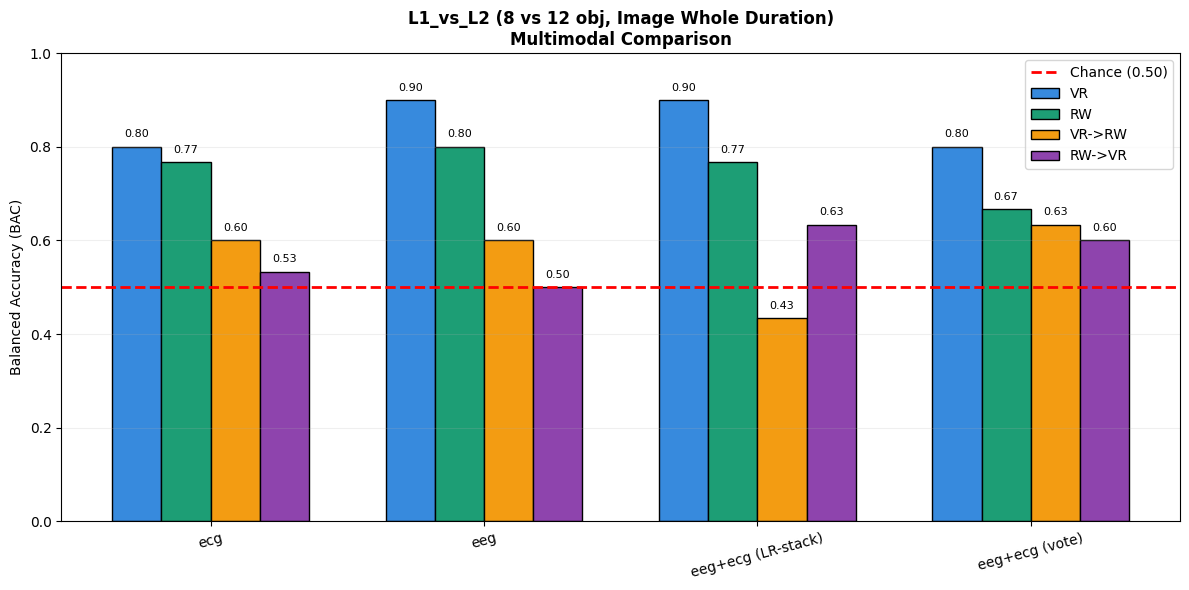

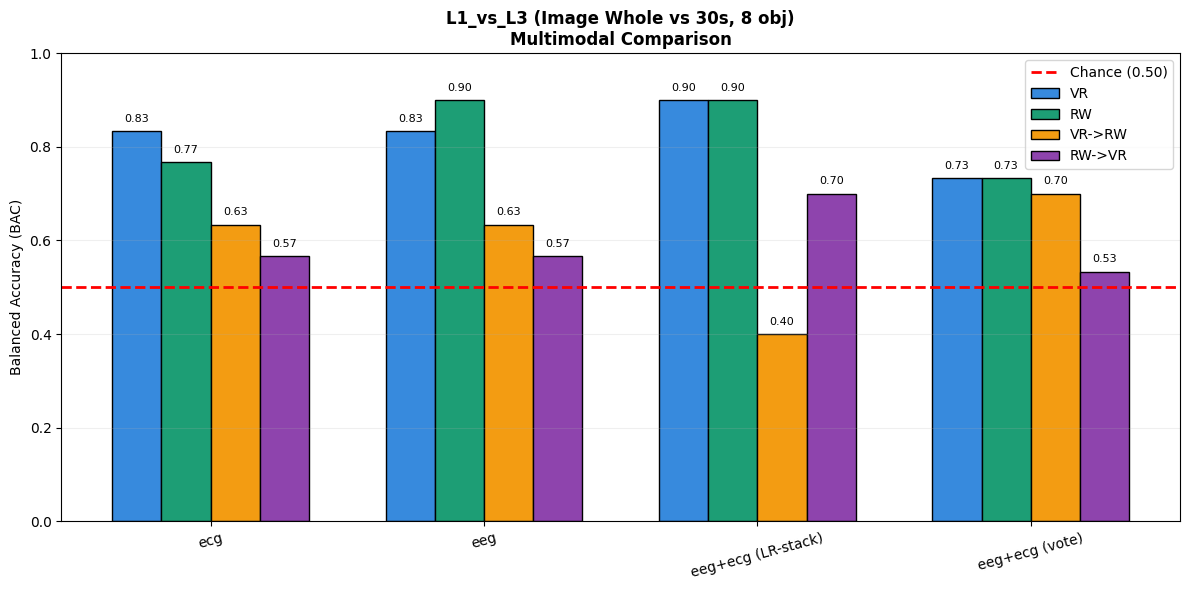

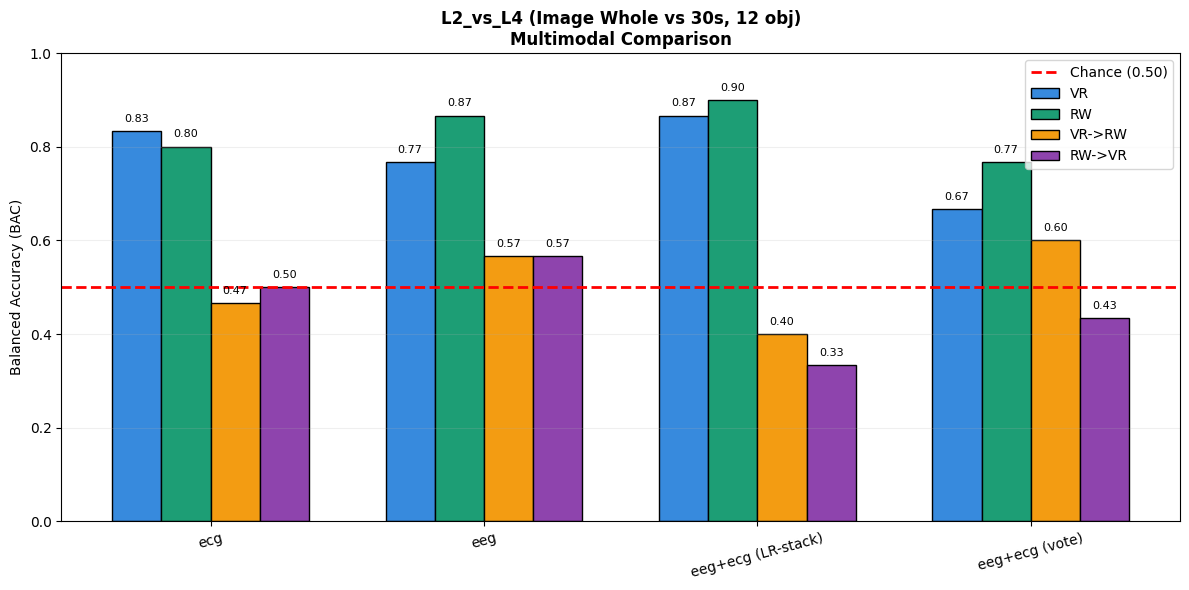

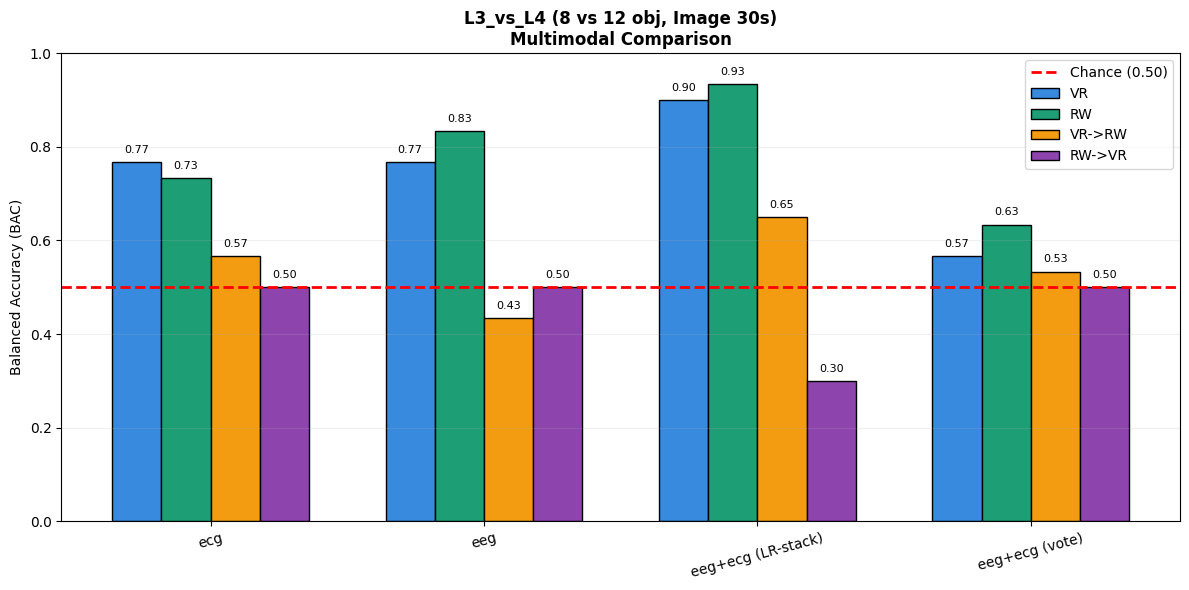

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PFIG = Path('./figures_presentation')
PFIG.mkdir(exist_ok=True)

WORLD_ORDER = ['VR', 'RW', 'VR->RW', 'RW->VR']

WORLD_COLORS = {
    'VR': '#378ADD',       # blue
    'RW': '#1D9E75',       # green
    'VR->RW': '#F39C12',   # orange
    'RW->VR': '#8E44AD',   # purple
}

def plot_multimodal_summary(summary):

    if summary.empty:
        print("No data to plot.")
        return

    for task_name, sub in summary.groupby('task', sort=False):

        piv = sub.pivot_table(
            index='model',
            columns='world',
            values='bac_mean',
            aggfunc='mean'
        )

        # enforce consistent column order
        cols = [c for c in WORLD_ORDER if c in piv.columns]
        piv = piv[cols]

        models = piv.index.tolist()
        x = np.arange(len(models))
        width = 0.18

        fig, ax = plt.subplots(figsize=(12, 6))

        # plot each world as a bar group
        for i, w in enumerate(cols):
            ax.bar(
                x + i*width,
                piv[w].values,
                width,
                label=w,
                color=WORLD_COLORS.get(w, '#95a5a6'),
                edgecolor='black'
            )

        # formatting
        ax.set_xticks(x + width*(len(cols)-1)/2)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel("Balanced Accuracy (BAC)")
        ax.set_title(f"{task_name}\nMultimodal Comparison", fontweight='bold')

        # chance lines
        if "4-Class" in task_name:
            ax.axhline(0.25, color='purple', linestyle=':', linewidth=2, label='Chance (0.25)')
        else:
            ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Chance (0.50)')

        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.2)

        # value labels
        for i, w in enumerate(cols):
            for j, val in enumerate(piv[w].values):
                ax.text(
                    j + i*width,
                    val + 0.02,
                    f"{val:.2f}",
                    ha='center',
                    fontsize=8
                )

        ax.legend()
        plt.tight_layout()

        fname = f"multimodal_{task_name.replace(' ','_').replace('(','').replace(')','')}.png"
        plt.savefig(PFIG / fname, dpi=200)
        plt.show()



plot_multimodal_summary(summary)

## output folder

```
fusion_outputs/
├── coverage_matrix.csv               who has which modalities
├── fusion_summary.csv                main comparison table (task × world × model)
├── per_participant_baseline_bac.csv  drill-down for the supplement
└── run_metadata.json                 seed, cohorts, task list
```

`fusion_summary.csv` is the headline file. Each row: `task | world | model | bac_mean | bac_std | n_participants`. `model` values include single modalities (`eeg`, `ecg`, `eye`), pairs (`eeg+ecg (vote)`, `eeg+ecg (LR-stack)`, …), and the tri-modal (`eeg+ecg+eye (vote)`, `eeg+ecg+eye (LR-stack)`). `world` includes `VR`, `RW`, `VR->RW`, `RW->VR`.

## Scaling to window-level fusion (later)

at some point to fuse at window-level granularity (one prediction per window per modality, as the GitLab reference describes for "block, window, subblock"):

1. Skip the trial-level aggregation in the EEG export — keep `window_idx` as a column.
2. Change `JOIN_KEY = ['world', 'trial_id', 'window_idx']` in cell 2 of this notebook.
3. Everything else still works. The classifier sees more samples per participant; LOO-CV is replaced by group-aware CV (group = trial) so windows from the same trial don't leak across train/test.